<a href="https://colab.research.google.com/github/rvit22bcs044rvitm-cod/HR-Attrition-Prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
####Problem Statement
Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
● Age
● Salary
● Job Role
● Job Satisfaction
● Work Experience
● Overtime
● Work-Life Balance
● Department
Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

#####Objective
The objective of this task is to:
● Understand and explore the HR dataset
● Perform data preprocessing (missing values, duplicates, outliers)
● Conduct Exploratory Data Analysis (EDA)
● Apply encoding and feature scaling
● Train multiple classification algorithms
● Evaluate models using classification metrics
● Perform cross-validation and hyperparameter tuning
● Select the best-performing model

Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

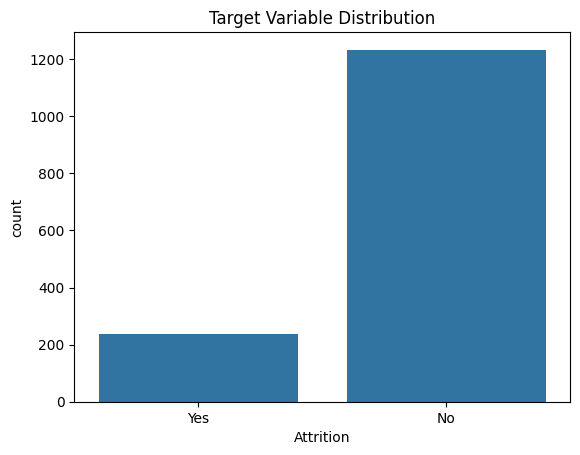

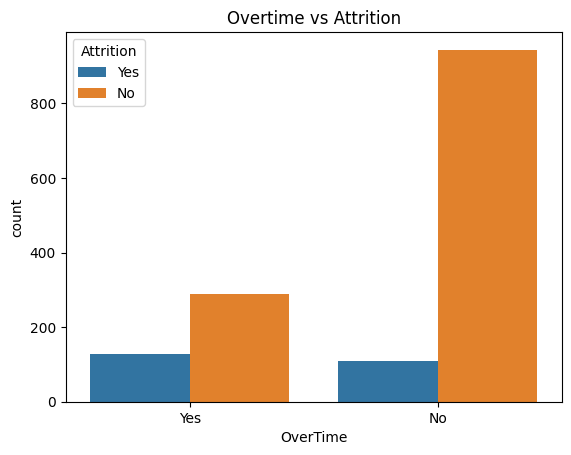

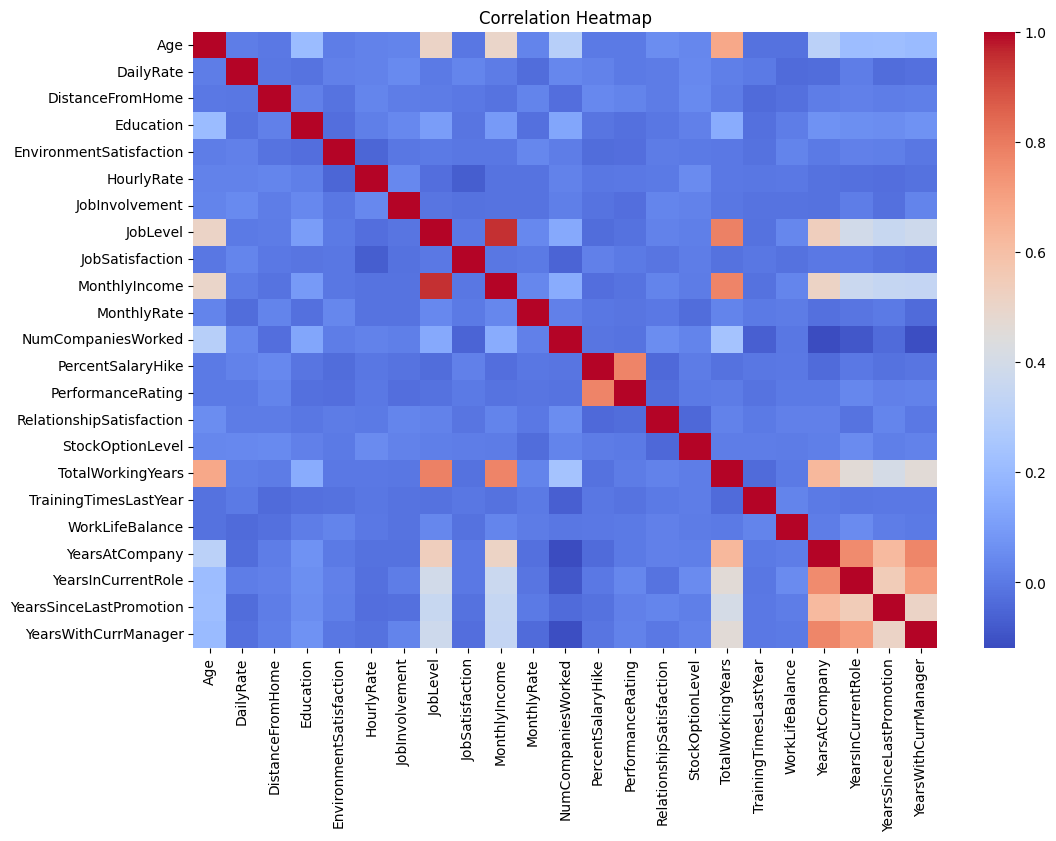

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.857143   0.571429  0.425532  0.487805  0.682402
1        Decision Tree  0.734694   0.275362  0.404255  0.327586  0.600913
2        Random Forest  0.816327   0.379310  0.234043  0.289474  0.580584
3                  KNN  0.761905   0.244444  0.234043  0.239130  0.548195
Best RF Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Top 5 Factors for Attrition:
StockOptionLevel         0.070614
MonthlyIncome            0.054656
JobSatisfaction          0.050082
MaritalStatus_Married    0.050004
Age                      0.040369
dtype: float64


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE


df = pd.read_csv('HR-Employee-Attrition.csv')


print(f"Shape: {df.shape}")
print(df.info())
print(df.describe().T)


df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)


sns.countplot(x='Attrition', data=df)
plt.title('Target Variable Distribution')
plt.show()

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Overtime vs Attrition')
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])


df = pd.get_dummies(df, drop_first=True)


X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_res, y_train_res)
print(f"Best RF Params: {grid_search.best_params_}")

best_rf = grid_search.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Factors for Attrition:")
print(importances.head(5))